In [1]:
import pandas as pd

df = pd.read_parquet("./results/scoring/merged.parquet")
df["NMSE"] = 1.0 / (df["pred_gain"] + 1e-8)
# assert (df.groupby(["explanation_type", "linear_coder"]).count() == n_test).all().all()


In [2]:
df.columns

Index(['explanation_type', 'model', 'estimator', 'document_idx',
       'train_dataset', 'train_split', 'test_dataset', 'test_split',
       'linear_coder', 'pred_gain', 'mse', 'l1', 'l2', 't', 'NMSE'],
      dtype='object')

In [3]:
import re

def extract_k(explanation_type):
    # Case: "The test instance (as a sanity check)"
    if "The test instance (as a sanity check)" in explanation_type:
        return 1

    # Case: "<number> by ... from Top-..."
    first_number_match = re.match(r"^\s*(\d+)\b", explanation_type)
    if first_number_match:
        return int(first_number_match.group(1))

    # Case: "Top-<number> ..." when no leading number
    top_match = re.search(r"Top-(\d+)", explanation_type)
    if top_match:
        return int(top_match.group(1))

    # Case: "<number> random examples"
    random_match = re.search(r"(\d+)\s+random examples", explanation_type)
    if random_match:
        return int(random_match.group(1))

    return None

# Apply to dataframe
df["k"] = df["explanation_type"].apply(extract_k)

# Replace the first occurrence of k in the string with "X"
def replace_k(explanation_type, k):
    if k is None:
        return explanation_type
    # Only replace the first occurrence of the number as a standalone word
    return re.sub(rf"\b{k}\b", "X", explanation_type, count=1)


import numpy as np

def vectorized_replace_k(explanation_types, ks):
    result = explanation_types.copy()
    for k in np.unique(ks[ks.notnull()]):  # only unique, non-null ks
        # Use string pattern, not compiled regex
        pattern = rf"\b{k}\b"
        mask = ks == k
        result.loc[mask] = result.loc[mask].str.replace(pattern, "X", n=1, regex=True)
    return result
df["explanation_type_no_k"] = vectorized_replace_k(df["explanation_type"], df["k"])


def facility_location_hotfix(x):
    if ("facility" in x) and x.startswith("Top-"):
        return x[len("Top-"):]
    else:
        return x
        
df["explanation_type"] = df["explanation_type"].apply(facility_location_hotfix) # hotfix: inconsistent naming scheme for facility location selections


def get_sort_type(x):
    for sort_type in ["scores with largest absolute value", "most positive scores", "most negative scores", "scores closest to zero"]:
        if sort_type in x:
            return sort_type
    return "-"
df["sort_type"] = df["explanation_type"].apply(get_sort_type)

In [4]:
from numpy import trapz
import numpy as np

import re

import os
import torch

In [5]:

def rename_model(x):
       if x == "OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_lr0.0001_seed42":
              return "Olmo2-1B"
       
def rename_estimator(x):
      return x.split(":")[0]
def rename_linear_coder(x):
      return x.replace("Coder","").replace("Thresh","")
def extract_seed(x):
       return int(re.search(r'seed (\d+)', x).group(1)) if "seed" in x else None

def rename_random(x):
    return re.sub(r' with seed \d+', "", x)
import re

import re

import re
def rename_explanation_type(x, include_k=True):
    x = x.replace("X", "2202")
    if "sanity check" in x.lower():
        return "Test instance"

    # "<number> random examples with seed <number>"
    m = re.match(r"(\d+) random examples with seed (\d+)", x)
    if m:
        return f"{m.group(1)} rand" if include_k else "rand"
    elif "random" in x:
        return "random"

    # "Top-k (least|most) (influential|helpful|harmful)"
    m = re.match(r"Top-(\d+) (least|most) (influential|helpful|harmful).*", x)
    if m:
        k, direction, kind = m.groups()
        abbrev = f"{k} {direction} {kind}" if include_k else f"{direction} {kind}"
        return abbrev.replace("influential", "inf.")

    # "<num> by facility location from Top-<num> ... lambda=<num>" OR "Top-<num> by facility location ..."
    m = re.match(
        r"(?:(\d+) by|Top-(\d+) by) facility location from Top-\d+ (least|most) (influential|helpful|harmful)(?:.*lambda=([\d.]+))?",
        x
    )
    if m:
        old_num, new_num, direction, kind, lam = m.groups()
        num = old_num or new_num
        if lam:
            if lam == "0.0":
                lam_clean = "0"
            else:
                lam_clean = lam.lstrip("0") if lam.startswith("0") else lam
                if lam_clean.endswith(".0"):
                    lam_clean = lam_clean[:-2]
            lam_str = f" $\\lambda={lam_clean}$"
        else:
            lam_str = ""
        prefix = f"{num} by" if include_k else ""
        abbrev = f"{prefix} FL {direction} {kind}{lam_str}"
        return abbrev.replace("influential", "inf.")
    
    
    
    # "<num> by DIVINE from Top-<num> ... lambda=<num>"
    m = re.match(
        r"(?:(\d+) by|Top-(\d+) by) DIVINE from Top-\d+ (least|most) (influential|helpful|harmful)",
        x
    )
    if m:
        old_num, new_num, direction, kind = m.groups()
        num = old_num or new_num
        prefix = f"{num} by" if include_k else ""
        abbrev = f"{prefix} DIVINE {direction} {kind}"
        return abbrev.replace("influential", "inf.")


    return x[:30] + "..." if len(x) > 30 else x


In [6]:
for x in df["explanation_type"].unique():
    print(f"{rename_explanation_type(x)} <---- {x}")

25 by DIVINE least inf. <---- 25 by DIVINE from Top-100 least influential (scores closest to zero).
10 by DIVINE most inf. <---- 10 by DIVINE from Top-100 most influential (scores with largest absolute value).
1 by DIVINE most helpful <---- 1 by DIVINE from Top-100 most helpful (most negative scores).
25 by DIVINE most inf. <---- 25 by DIVINE from Top-100 most influential (scores with largest absolute value).
1 most helpful <---- Top-1 most helpful (most negative scores)
5 most helpful <---- Top-5 most helpful (most negative scores)
10 most helpful <---- Top-10 most helpful (most negative scores)
25 most helpful <---- Top-25 most helpful (most negative scores)
1 most harmful <---- Top-1 most harmful (most positive scores)
25 by DIVINE most helpful <---- 25 by DIVINE from Top-100 most helpful (most negative scores).
10 by FL most inf. $\lambda=0$ <---- 10 by facility location from Top-100 most influential (scores with largest absolute value). lambda=0.0
10 by FL least inf. $\lambda=0$ <

## Analysis of linear_coders

In [7]:
cols_to_display = ['explanation_type', 'model', 'estimator', "k", 
    #    'train_dataset', 'train_split', 'test_dataset', 'test_split',   'linear_coder',  't', 'k', 'explanation_type_no_k'
     'linear_coder',"l1", "l2", "Prop. non-zero",
       "Prop. negative"
      ]




In [8]:
df["seed"] = df["explanation_type"].apply(extract_seed).fillna(-1)

df["linear_coder"] = df["linear_coder"].apply(rename_linear_coder)
softplus = torch.nn.Softplus()

# df["sum Softplus(t)"] = df["t"].apply(lambda t: float(softplus(torch.tensor(t)).sum()))
# df["sum(t)"] = df["t"].apply(lambda t: sum(t))

df["Prop. non-zero"] = df.apply(lambda row: np.count_nonzero(row["t"]) / len(row["t"]), axis=1)
df["Prop. negative"] = df.apply(lambda row: np.count_nonzero(row["t"] < 0) / len(row["t"]), axis=1)

table = df.groupby(["model", 'train_dataset', 'train_split', 'test_dataset', 'test_split',"estimator", "seed",
       'linear_coder',"explanation_type","explanation_type_no_k","k",]).mean(numeric_only=True).reset_index()[cols_to_display]


table["explanation_type"] = table["explanation_type"].apply(rename_random)

table["model"] = table["model"].apply(rename_model)
table["estimator"] = table["estimator"].apply(rename_estimator)

# macro avg over random selections
table = table.groupby(["k", "linear_coder"]).mean(numeric_only=True).reset_index()[["k", 'linear_coder',
       'l1',"l2","Prop. non-zero", "Prop. negative"
      ]]
# table["k"] = table["k"].apply(lambda x: str(int(x)))
#table = table.set_index(["model", "k"]).sort_values(by=["model", "k",], ascending=False)
# table["NMSE"] = table["NMSE"].apply(lambda x: f"{x:.2e}") 

table = table.set_index(["k","linear_coder"]).sort_values(by=["k"])


In [9]:
macro_avg = table.groupby('linear_coder').mean(numeric_only=True).reset_index()
macro_avg['k'] = 'macro_avg' 
table_with_macro = pd.concat([table.reset_index(), macro_avg], ignore_index=True)
table_with_macro = table_with_macro.set_index(['k','linear_coder']).sort_index()


In [10]:
def heatmap_per_group(df, group_col):
    styled = df.style

    for _, group in df.groupby(group_col):
        idx = group.index

        # l1, l2 → lower is better → green for low values
        for col in ['l2', 'l1', "Prop. negative", "Prop. non-zero"]:
            styled = styled.background_gradient(
                cmap='Greens_r', subset=pd.IndexSlice[idx, [col]]
            )

      
       
    return styled
styled_table = heatmap_per_group(table_with_macro.reset_index(), group_col='k')
styled_table

,k,linear_coder,l1,l2,Prop. non-zero,Prop. negative
0,1,KLT,0.000000,0.000000,0.834556,0.372778
1,1,MSE,0.161491,41.694655,0.834556,0.367806
2,1,MSENNLSL2,0.070139,0.054379,0.466750,0.000000
3,1,MSEProjUSimp,1.000000,1.000000,1.000000,0.000000
4,1,MSEProjUSimpSparse,1.000000,1.000000,1.000000,0.000000
5,1,MSEProjUSimpSparseSoft,1.000000,1.000000,1.000000,0.000000
6,5,KLT,0.071579,0.038884,0.850048,0.425121
7,5,MSE,0.073750,0.053711,0.850048,0.416558
8,5,MSENNLSL2,0.056256,0.130354,0.382364,0.000000
9,5,MSEProjUSimp,1.000000,0.212528,0.990442,0.000000


In [11]:
styled_table = heatmap_per_group(macro_avg.reset_index(), group_col='k').hide(axis="columns", subset=["k","index"]).hide(axis="index").format({col: "{:.2f}" for col in styled_table.data.select_dtypes(include="number").columns})
styled_table

linear_coder,l1,l2,Prop. non-zero,Prop. negative
KLT,0.07,0.03,0.85,0.41
MSE,0.11,10.46,0.85,0.41
MSENNLSL2,0.21,1.26,0.38,0.00
MSEProjUSimp,1.00,0.34,0.99,0.00
MSEProjUSimpSparse,1.01,0.47,0.59,0.00
MSEProjUSimpSparseSoft,1.00,0.34,0.99,0.00


In [12]:

# Ensure output folder exists
os.makedirs("./tables/", exist_ok=True)

# Export LaTeX with colors
latex_tabular = styled_table.format_index(escape="latex", axis=1).format_index(escape="latex", axis=0).to_latex(
    convert_css=True,   # Converts background colors to \cellcolor
  
    hrules=True,
    column_format='l' + 'c'*(len(styled_table.data.columns))  # Adjust column alignment
)

latex_table = (
    "\\begin{table}[ht]\n"
    "\\scriptsize\n"
    "\\centering\n"
    "\\setlength{\\tabcolsep}{3pt}  % Default is 6pt, reduce for tighter columns\n"
    "\\caption{Statistics for coefficent vector $t$ with different linear coders.}"
    "\\label{tab:linear_coder_selection}\n"
    f"{latex_tabular}\n"
    "\\end{table}\n"
)

with open("./tables/linear_coder_selection.tex", "w") as f:
    f.write(latex_table)

## Quality Score Results per Model and Estimator

In [13]:
df.groupby("estimator").count()

,explanation_type,model,document_idx,train_dataset,train_split,test_dataset,test_split,linear_coder,pred_gain,mse,l1,l2,t,NMSE,k,explanation_type_no_k,sort_type,seed,Prop. non-zero,Prop. negative
estimator,,,,,,,,,,,,,,,,,,,,
"BM25Estimator: k1=1.5, b=0.75",222000,222000,222000,222000,222000,222000,222000,222000,222000,222000,222000,222000,222000,222000,222000,222000,222000,222000,222000,222000
DataInfEstimator: fast_implementation=True,294332,294332,294332,294332,294332,294332,294332,294332,294332,294332,294332,294332,294332,294332,294332,294332,294332,294332,294332,294332
LESSEstimator: normalize=True,294000,294000,294000,294000,294000,294000,294000,294000,294000,294000,294000,294000,294000,294000,294000,294000,294000,294000,294000,294000


In [14]:
cols_to_display = ['explanation_type', 'model', 'estimator', "k","sort_type",#'l1', 'l2',
    #    'train_dataset', 'train_split', 'test_dataset', 'test_split',   'linear_coder',  't', 'k', 'explanation_type_no_k'
       'NMSE', #'linear_coder', 'pred_gain',
      ]
linear_coder = "MSEProjUSimp"#"MSECoderProjUSimpSparse"




In [15]:


df["seed"] = df["explanation_type"].apply(extract_seed).fillna(-1)
df
df_filtered = df[df["linear_coder"] == linear_coder]

# df_filtered = df_filtered[~(df_filtered["explanation_type"].str.contains("facility")) | ((df_filtered["explanation_type"].str.contains("lambda=0.5")))]
# df_filtered = df_filtered[
#     df_filtered["sort_type"].str.contains("scores with largest absolute value|most negative scores|-", regex=True, case=False)
# ]

df_at_k_10 = df_filtered[df_filtered["k"] == 10]




In [16]:
import os

def style_and_export_table(table, col="NMSE", filename="table", cmap="PuBu",fmt="sci", sort=True):
  
    if fmt == "pct":
        fmt_str = "{:.2%}"
    elif fmt == "sci":
        fmt_str = "{:.2e}"
    else:
        raise ValueError("fmt invalid")

    # Set multi-index and sort
    
    if sort:
        table = table.sort_values(
            by=[col], ascending=True
        )
    table = table.set_index(["model", "k", "estimator", "sort_type"])
    
    # Styling for display
    styled = (
        table.reset_index()
        .style.background_gradient(subset=[col], cmap=cmap)
        .format({col: fmt_str})
        .hide(axis="columns", subset=["k", "sort_type", "estimator"])
        .hide(axis="index")
    )

    display(styled)

    # Ensure directory exists
    os.makedirs(f"./tables/scoring/{col}", exist_ok=True)

    # Export LaTeX table with cell colors
    latex_tabular = styled.format_index(escape="latex", axis=1).format_index(
        escape="latex", axis=0
    ).to_latex(
        convert_css=True,
        hrules=True,
        column_format='l|l|l'  # adjust as needed
    )

    with open(f"./tables/scoring/{col}/{filename}.tex", "w") as f:
        f.write(latex_tabular)

    return styled


In [17]:

pairs = [
("full_per_estimator_model_selection_k_10", df_at_k_10),
("full_per_estimator_model_selection", df_filtered)
]

pairs += [
(f"full_per_estimator_model_selection_k_10_{estimator.split(':')[0]}", df_at_k_10[df_at_k_10["estimator"] == estimator])
for estimator in df_at_k_10["estimator"].unique()
]

for filename, ddf in pairs:
       table =ddf.groupby(["model", 'train_dataset', 'train_split', 'test_dataset', 'test_split',"estimator", "seed",
              'linear_coder',"explanation_type","explanation_type_no_k","k","sort_type"]).mean(numeric_only=True).reset_index()[cols_to_display]


       table["explanation_type"] = table["explanation_type"].apply(rename_random)
       table["explanation_type"]= table["explanation_type"].apply(lambda x: rename_explanation_type(x, include_k=False))
       
       table["model"] = table["model"].apply(rename_model)

       table["estimator"] = table["estimator"].apply(rename_estimator)



       table_agg = table.groupby(["estimator", 'explanation_type', 'model', 'sort_type',]).mean(numeric_only=True).reset_index()

       # mean across the 3 per-estimator random rows
       table_agg.loc[table_agg["explanation_type"].str.contains("random"), "estimator"] = "-"
       table_agg = table_agg.groupby(["estimator", 'explanation_type', 'model', 'sort_type',]).mean(numeric_only=True).reset_index()
       
       table = table_agg[cols_to_display]
       
       table["k"] = table["k"].apply(lambda x: str(int(x)))
       
       
       style_and_export_table(table, col="NMSE", filename=filename)


model,explanation_type,NMSE
Olmo2-1B,FL least inf. $\lambda=0$,1.01e+00
Olmo2-1B,DIVINE least inf.,9.04e+05
Olmo2-1B,least inf.,9.04e+05
Olmo2-1B,DIVINE least inf.,9.04e+05
Olmo2-1B,least inf.,9.04e+05
Olmo2-1B,least inf.,9.57e+05
Olmo2-1B,DIVINE least inf.,9.57e+05
Olmo2-1B,random,9.81e+05
Olmo2-1B,DIVINE most inf.,1.03e+06
Olmo2-1B,most inf.,1.03e+06


model,explanation_type,NMSE
Olmo2-1B,FL least inf. $\lambda=0$,1.01e+00
Olmo2-1B,Test instance,9.04e+05
Olmo2-1B,Test instance,9.04e+05
Olmo2-1B,Test instance,9.04e+05
Olmo2-1B,DIVINE least inf.,9.04e+05
Olmo2-1B,least inf.,9.04e+05
Olmo2-1B,DIVINE least inf.,9.04e+05
Olmo2-1B,least inf.,9.04e+05
Olmo2-1B,DIVINE least inf.,9.63e+05
Olmo2-1B,least inf.,9.63e+05


model,explanation_type,NMSE
Olmo2-1B,FL least inf. $\lambda=0$,1.01e+00
Olmo2-1B,DIVINE least inf.,9.04e+05
Olmo2-1B,least inf.,9.04e+05
Olmo2-1B,random,9.81e+05
Olmo2-1B,most harmful,1.33e+06
Olmo2-1B,DIVINE most helpful,1.34e+06
Olmo2-1B,most helpful,1.34e+06
Olmo2-1B,DIVINE most inf.,1.43e+06
Olmo2-1B,most inf.,1.43e+06
Olmo2-1B,FL most inf. $\lambda=0$,1.96e+06


model,explanation_type,NMSE
Olmo2-1B,least inf.,9.57e+05
Olmo2-1B,DIVINE least inf.,9.57e+05
Olmo2-1B,random,9.81e+05
Olmo2-1B,DIVINE most inf.,1.03e+06
Olmo2-1B,most inf.,1.03e+06


model,explanation_type,NMSE
Olmo2-1B,DIVINE least inf.,9.04e+05
Olmo2-1B,least inf.,9.04e+05
Olmo2-1B,random,9.81e+05
Olmo2-1B,most harmful,1.36e+06
Olmo2-1B,most helpful,1.37e+06
Olmo2-1B,DIVINE most helpful,1.37e+06
Olmo2-1B,DIVINE most inf.,1.43e+06
Olmo2-1B,most inf.,1.43e+06


In [18]:
results = []
for name, group in df_filtered.groupby(["model", 'train_dataset', 'train_split', 'test_dataset', 'test_split',"estimator",
       'linear_coder',"explanation_type_no_k","k",]).mean(numeric_only=True).groupby(["model", 'train_dataset', 'train_split', 'test_dataset', 'test_split',"estimator",
       'linear_coder',"explanation_type_no_k"]):
       dff = group.reset_index().sort_values(by="k")

       if len(dff) < 2:
              continue  
       result_dict = dff.iloc[0][[
              'model', 'train_dataset', 'train_split', 'test_dataset', 'test_split',"estimator",
              'linear_coder', 'explanation_type_no_k'
       ]].to_dict()


       result_dict['auc_NMSE'] = np.trapz(dff["NMSE"], dff["k"])
       result_dict['count'] = len(dff)
       results.append(result_dict)
df_auc = pd.DataFrame(results)

In [19]:
cols_to_use = ["model", "k","sort_type", "estimator", "explanation_type_no_k", "auc_NMSE"]
df_auc.loc[:,"k"] = 0

df_auc.loc[:,"sort_type"] = 0
table_auc = df_auc[cols_to_use]
table_auc.loc[:,"explanation_type_no_k"] = table_auc["explanation_type_no_k"].apply(lambda x: x if "random" not in x else "random")
table_auc = table_auc.groupby(["model", "explanation_type_no_k", "estimator"]).mean().reset_index() # mean across random per estimator

table_auc["explanation_type_no_k"] = table_auc["explanation_type_no_k"].apply(rename_random)
table_auc["explanation_type_no_k"]= table_auc["explanation_type_no_k"].apply(lambda x: rename_explanation_type(x, include_k=False))
    
table_auc["model"] = table_auc["model"].apply(rename_model)


    
for estimator in df_at_k_10["estimator"].unique():
    table_auc_ = table_auc[table_auc["estimator"] == estimator]
    table_auc_.loc[:,"estimator"] = table_auc_["estimator"].apply(rename_estimator)
    style_and_export_table(table_auc_, col="auc_NMSE", filename=f"full_per_estimator_model_selection_auc_{estimator.split(':')[0]}", cmap="Oranges")
    1

model,explanation_type_no_k,auc_NMSE
Olmo2-1B,DIVINE least inf.,2.17e+07
Olmo2-1B,least inf.,2.17e+07
Olmo2-1B,random,2.38e+07
Olmo2-1B,most harmful,3.30e+07
Olmo2-1B,DIVINE most helpful,3.31e+07
Olmo2-1B,most helpful,3.31e+07
Olmo2-1B,DIVINE most inf.,3.54e+07
Olmo2-1B,most inf.,3.54e+07


model,explanation_type_no_k,auc_NMSE
Olmo2-1B,DIVINE least inf.,2.31e+07
Olmo2-1B,least inf.,2.31e+07
Olmo2-1B,random,2.38e+07
Olmo2-1B,DIVINE most inf.,2.47e+07
Olmo2-1B,most inf.,2.47e+07


model,explanation_type_no_k,auc_NMSE
Olmo2-1B,DIVINE least inf.,2.17e+07
Olmo2-1B,least inf.,2.17e+07
Olmo2-1B,random,2.38e+07
Olmo2-1B,most harmful,3.36e+07
Olmo2-1B,DIVINE most helpful,3.36e+07
Olmo2-1B,most helpful,3.36e+07
Olmo2-1B,DIVINE most inf.,3.57e+07
Olmo2-1B,most inf.,3.57e+07


In [20]:
df.linear_coder.unique()

array(['MSEProjUSimp', 'KLT', 'MSE', 'MSENNLSL2', 'MSEProjUSimpSparse',
       'MSEProjUSimpSparseSoft'], dtype=object)

In [21]:
# os.makedirs("./tables/scoring", exist_ok=True)


# latex_tabular = table.to_latex(
#     index=False,
#     longtable=False,
#     float_format="%.4f",
#     escape=True,
# )


# latex_table = (
#     "\\begin{table*}[htbp]\n"
#     "\\scriptsize\n"
#     "\\centering\n"
#     "\\caption{Aggregate results across budgets for different selection strategies "
#     "(mean or auc across $k=\\{1,5,10,25\\}$)}\n"
#     "\\label{tab:aggregate_results}\n"
#     f"{latex_tabular}\n"
#     "\\end{table*}\n"
# )


# with open("./tables/scoring/aggregate_results.tex", "w") as f:
#     f.write(latex_table)

In [22]:
import re

def get_tuples():
    results = []
    explanation_types = df["explanation_type"].unique()
    top_items = {re.match(r'Top-(\d+)\s+(.*)', d).groups()
                 for d in explanation_types if d.startswith("Top-")}
    
    for d in explanation_types:
        if "by facility location" not in d:
            continue
        
  
        num_match = re.match(r'(\d+)\s+by facility location.*from Top-\d+\s+(.*)\. lambda', d)
        if not num_match:
            continue
        
        num, typ = num_match.groups()
        typ = typ.strip()  
        
       
        match = next((f"Top-{n} {t}" for n, t in top_items if n == num and t == typ), None)
        if match:
            assert d in explanation_types and match in explanation_types
            results.append((d, match))
    for d in explanation_types:
        if "by DIVINE" not in d:
            continue
        
  
        num_match = re.match(r'(\d+)\s+by DIVINE.*from Top-\d+\s+(.*)\. lambda', d)
        if not num_match:
            continue
        
        num, typ = num_match.groups()
        typ = typ.strip()  
        
       
        match = next((f"Top-{n} {t}" for n, t in top_items if n == num and t == typ), None)
        if match:
            assert d in explanation_types and match in explanation_types
            results.append((d, match))
    return results

df_comp = []
for fl_selection_type, naive_selection_type in get_tuples():
    df_filtered = df[df["explanation_type"].isin([fl_selection_type, naive_selection_type])].copy()
    df_filtered["type"] = df_filtered["explanation_type"].map({
        fl_selection_type: "fl",
        naive_selection_type: "naive"
    })
    

    df_m = (
    
        df_filtered[df_filtered["linear_coder"] == "MSEProjUSimp"].groupby(
            [
                "model", "estimator", #"document_idx",
                "train_dataset", "train_split", "test_dataset",
                "test_split", "linear_coder", "type", "k", "sort_type"
            ]
        ).mean(numeric_only=True)
        
    ).reset_index()
    df_m["setting"] = fl_selection_type
    df_comp.append(df_m.pivot_table(index=["model", "estimator", "train_dataset", "train_split",
                        "test_dataset", "test_split", "linear_coder","setting","k", "sort_type"],
                 columns="type",
                 values=["NMSE"]).reset_index())#, "l1", "l2"]))
    
df_comp = pd.concat(df_comp).dropna()
df_comp["NMSE_reduction_pct"] = (1 - df_comp[('NMSE', 'fl')] / df_comp[('NMSE', 'naive')]) #* 100
df_comp.columns = df_comp.columns.get_level_values(0)
df_comp

,model,estimator,train_dataset,train_split,test_dataset,test_split,linear_coder,setting,k,sort_type,NMSE,NMSE,NMSE_reduction_pct
1,OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_...,DataInfEstimator: fast_implementation=True,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,MSEProjUSimp,10 by facility location from Top-100 most infl...,10,scores with largest absolute value,1.955922e+06,1.432725e+06,-0.365176
1,OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_...,DataInfEstimator: fast_implementation=True,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,MSEProjUSimp,10 by facility location from Top-100 least inf...,10,scores closest to zero,1.012374e+00,9.040779e+05,0.999999


In [23]:
df["explanation_type"].unique()

array(['25 by DIVINE from Top-100 least influential (scores closest to zero).',
       '10 by DIVINE from Top-100 most influential (scores with largest absolute value).',
       '1 by DIVINE from Top-100 most helpful (most negative scores).',
       '25 by DIVINE from Top-100 most influential (scores with largest absolute value).',
       'Top-1 most helpful (most negative scores)',
       'Top-5 most helpful (most negative scores)',
       'Top-10 most helpful (most negative scores)',
       'Top-25 most helpful (most negative scores)',
       'Top-1 most harmful (most positive scores)',
       '25 by DIVINE from Top-100 most helpful (most negative scores).',
       '10 by facility location from Top-100 most influential (scores with largest absolute value). lambda=0.0',
       '10 by facility location from Top-100 least influential (scores closest to zero). lambda=0.0',
       '1 random examples with seed 9', '10 random examples with seed 9',
       '1 random examples with seed 6', '5

In [24]:
import pandas as pd
import re


def get_tuples():
    results = []
    explanation_types = df["explanation_type"].unique()
    top_items = {re.match(r'Top-(\d+)\s+(.*)', d).groups()
                 for d in explanation_types if d.startswith("Top-")}
    
    for d in explanation_types:
        if "by facility location" not in d:
            continue
        
  
        num_match = re.match(r'(\d+)\s+by facility location.*from Top-\d+\s+(.*)\. lambda', d)
        if not num_match:
            continue
        
        num, typ = num_match.groups()
        typ = typ.strip()  
        
       
        match = next((f"Top-{n} {t}" for n, t in top_items if n == num and t == typ), None)
        if match:
            assert d in explanation_types and match in explanation_types
            results.append((d, match))
    for d in explanation_types:
        if "by DIVINE" not in d:
            continue
        
  
        num_match = re.match(r'(\d+)\s+by DIVINE from Top-\d+\s+(.*)\.', d)
        if not num_match:
            continue
        
        num, typ = num_match.groups()
        typ = typ.strip()  
        
       
        match = next((f"Top-{n} {t}" for n, t in top_items if n == num and t == typ), None)
        if match:
            assert d in explanation_types and match in explanation_types
            results.append((d, match))
    return results


df_comp_list = []

for fl_selection_type, naive_selection_type in get_tuples():

    df_filtered = df[df["explanation_type"].isin([fl_selection_type, naive_selection_type])].copy()
    df_filtered["type"] = df_filtered["explanation_type"].map({
        fl_selection_type: "fl",
        naive_selection_type: "naive"
    })
    

    df_filtered = df_filtered[df_filtered["linear_coder"] == "MSEProjUSimp"]

  
    df_pivot = df_filtered.pivot_table(
        index=["model", "estimator", "train_dataset", "train_split",
               "test_dataset", "test_split", "linear_coder", "k", "sort_type"],
        columns="type",
        values="NMSE"
    ).reset_index()
    
 
    df_pivot["NMSE_reduction_pct"] = (1 - df_pivot["fl"] / df_pivot["naive"])  # mean of pairwise 
    
   
    df_pivot["setting"] = fl_selection_type
    
    df_comp_list.append(df_pivot)


df_comp = pd.concat(df_comp_list).dropna().reset_index(drop=True)


In [25]:
get_tuples()

[('10 by facility location from Top-100 most influential (scores with largest absolute value). lambda=0.0',
  'Top-10 most influential (scores with largest absolute value)'),
 ('10 by facility location from Top-100 least influential (scores closest to zero). lambda=0.0',
  'Top-10 least influential (scores closest to zero)'),
 ('25 by DIVINE from Top-100 least influential (scores closest to zero).',
  'Top-25 least influential (scores closest to zero)'),
 ('10 by DIVINE from Top-100 most influential (scores with largest absolute value).',
  'Top-10 most influential (scores with largest absolute value)'),
 ('1 by DIVINE from Top-100 most helpful (most negative scores).',
  'Top-1 most helpful (most negative scores)'),
 ('25 by DIVINE from Top-100 most influential (scores with largest absolute value).',
  'Top-25 most influential (scores with largest absolute value)'),
 ('25 by DIVINE from Top-100 most helpful (most negative scores).',
  'Top-25 most helpful (most negative scores)'),
 ('

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

def get_lambda(x):
    match = re.search(r'lambda=([\d.]+)', x)
    return float(match.group(1)) if match else "-"


In [27]:
table = df_comp.sort_values(ascending=False,by=(['k','NMSE_reduction_pct']))[["model", "estimator",  "setting", "NMSE_reduction_pct","k", "sort_type"]]


table["model"] = table["model"].apply(rename_model)



for estimator in df_at_k_10["estimator"].unique():
    style_and_export_table(table[table["estimator"] == estimator], col="NMSE_reduction_pct", filename=f"NMSE_reduction_{estimator.split(':')[0]}", cmap="Purples",fmt="pct",sort=True)


model,setting,NMSE_reduction_pct
Olmo2-1B,10 by facility location from Top-100 most influential (scores with largest absolute value). lambda=0.0,-36.52%
Olmo2-1B,1 by DIVINE from Top-100 most helpful (most negative scores).,0.00%
Olmo2-1B,1 by DIVINE from Top-100 least influential (scores closest to zero).,0.00%
Olmo2-1B,1 by DIVINE from Top-100 most influential (scores with largest absolute value).,0.00%
Olmo2-1B,25 by DIVINE from Top-100 least influential (scores closest to zero).,0.00%
Olmo2-1B,10 by DIVINE from Top-100 least influential (scores closest to zero).,0.00%
Olmo2-1B,5 by DIVINE from Top-100 least influential (scores closest to zero).,0.00%
Olmo2-1B,5 by DIVINE from Top-100 most helpful (most negative scores).,0.00%
Olmo2-1B,5 by DIVINE from Top-100 most influential (scores with largest absolute value).,0.00%
Olmo2-1B,25 by DIVINE from Top-100 most helpful (most negative scores).,0.01%


model,setting,NMSE_reduction_pct
Olmo2-1B,10 by DIVINE from Top-100 least influential (scores closest to zero).,-0.00%
Olmo2-1B,5 by DIVINE from Top-100 most influential (scores with largest absolute value).,-0.00%
Olmo2-1B,1 by DIVINE from Top-100 least influential (scores closest to zero).,0.00%
Olmo2-1B,1 by DIVINE from Top-100 most influential (scores with largest absolute value).,0.00%
Olmo2-1B,10 by DIVINE from Top-100 most influential (scores with largest absolute value).,0.00%
Olmo2-1B,5 by DIVINE from Top-100 least influential (scores closest to zero).,0.00%
Olmo2-1B,25 by DIVINE from Top-100 least influential (scores closest to zero).,0.00%
Olmo2-1B,25 by DIVINE from Top-100 most influential (scores with largest absolute value).,0.11%


model,setting,NMSE_reduction_pct
Olmo2-1B,10 by DIVINE from Top-100 most helpful (most negative scores).,-0.00%
Olmo2-1B,1 by DIVINE from Top-100 most helpful (most negative scores).,0.00%
Olmo2-1B,1 by DIVINE from Top-100 least influential (scores closest to zero).,0.00%
Olmo2-1B,1 by DIVINE from Top-100 most influential (scores with largest absolute value).,0.00%
Olmo2-1B,25 by DIVINE from Top-100 least influential (scores closest to zero).,0.00%
Olmo2-1B,10 by DIVINE from Top-100 least influential (scores closest to zero).,0.00%
Olmo2-1B,5 by DIVINE from Top-100 least influential (scores closest to zero).,0.00%
Olmo2-1B,25 by DIVINE from Top-100 most helpful (most negative scores).,0.01%
Olmo2-1B,25 by DIVINE from Top-100 most influential (scores with largest absolute value).,0.02%
Olmo2-1B,5 by DIVINE from Top-100 most influential (scores with largest absolute value).,0.03%


In [28]:
from matplotlib.ticker import FuncFormatter


/root/.local/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._figure.tight_layout(*args, **kwargs)


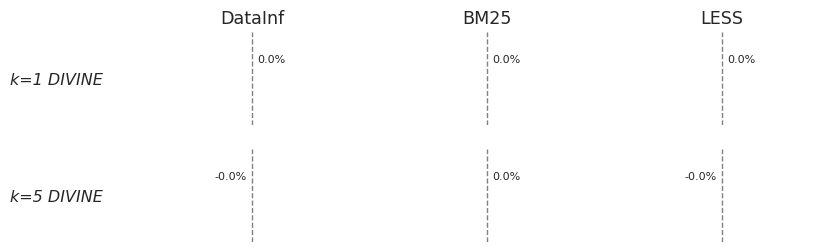

/root/.local/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  self._figure.tight_layout(*args, **kwargs)


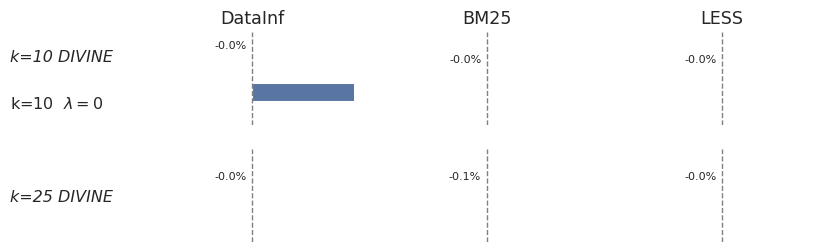

In [ ]:
table["lambda"] = table["setting"].apply(get_lambda)
table["NMSE_improvement_pct"] = -table["NMSE_reduction_pct"]
fff = table[ (table["setting"].str.contains("largest absolute"))]
fff.loc[:,"sort_type"] = fff["setting"].str.contains("DIVINE")
fff.loc[:,"setting"] = fff["setting"].apply(rename_explanation_type)




for name, part in [("1_5", (fff["k"] == 1) | (fff["k"] == 5)), ("10_25",(fff["k"] == 10) | (fff["k"] ==25))]:
    sns.set(style="whitegrid")
    col_order = ["DataInfEstimator: fast_implementation=True", "BM25Estimator: k1=1.5, b=0.75", "LESSEstimator: normalize=True"]
    sns.set_context("talk", font_scale=0.7) 

    g = sns.catplot(
        data=fff[part].groupby(["k", "estimator", "setting", "model","lambda", "sort_type"], as_index=False)["NMSE_improvement_pct"].mean().sort_values(by=["sort_type","k","lambda"], ascending=[False, True, True]),
        kind="bar",
        x="NMSE_improvement_pct",
        y="setting",
        col="estimator",
        row="k",
        col_order=col_order,
        hue="model",
        height=1.5,
        palette="deep",
        aspect=1.5,
        orient="h",
        sharey=False,
    )

    for ax in g.axes.flatten():
        ticks = ax.get_yticks()
        labels = [
        "k=" + lbl.get_text().replace("by FL most inf.", "").replace("by DIVINE most inf.", "DIVINE")
            for lbl in ax.get_yticklabels()
        ]
        ax.set_yticks(ticks)
        ax.set_yticklabels(labels, ha='left')

    for row_axes in g.axes:
        for ax in row_axes[1:]:
            ax.set_ylabel("")
            ax.set_yticklabels([])

    for ax in g.axes.flatten():
        # ax.xaxis.set_major_formatter(PercentFormatter(1.0))
        ax.set_xticklabels([])     
        ax.set_xticks([]) 
    for ax, title in zip(g.axes[0, :], g.col_names):
        clean_title = title.split(":")[0].replace("Estimator","")
        ax.set_title(clean_title)
    for row_axes in g.axes[1:]:
        for ax in row_axes:
            ax.set_title("")

    g.set_axis_labels("NMSE Improvement (%)", "Setting")
    g.set_ylabels("") 
    g.set_xlabels("") 

    plt.tight_layout()
    g.fig.subplots_adjust(
        top=0.85,
        bottom=0.15,
        left=0.12,
        right=0.95,
        hspace=0.25,
        wspace=0.15
    )

    for ax in g.axes.flatten():
        ax.set_xlim(-0.25, 0.8)
        ax.xaxis.set_major_formatter(
            FuncFormatter(lambda x, pos: f"{int(x * 100)}%")
        )
        ax.axvline(0, color='gray', linewidth=1, linestyle='--')

        for container in ax.containers:
            plt.setp(container, height=0.4)
            for bar in container:
                width = bar.get_width()
                if width >= 0:
                    x = width + 0.005
                    ha = 'left'
                else:
                    x = width - 0.005
                    ha = 'right'
                ax.text(x, bar.get_y() + bar.get_height()/2,
                        f"{width*100:.1f}%",
                        va='center', ha=ha, fontsize=8)

    g._legend.remove()

    tol = 1e-8
    for ax in g.axes.flatten():
        ax.set_xlim(-0.1,0.1)
        for line in ax.get_xgridlines():
            x_pos = line.get_xdata()[0]
            if abs(x_pos) > tol:
                line.set_visible(False)
            

    sns.despine(left=True, bottom=True, right=True)

    for ax in g.axes.flatten():
        ax.grid(False)
        ax.tick_params(left=False, bottom=False)

    for row_axes in g.axes:
        ax = row_axes[0]
        for label in ax.get_yticklabels():
            label.set_x(-0.6)


# Create a mapping from setting -> sort_type
    sort_type_map = fff.set_index("setting")["sort_type"].to_dict()

    for ax in g.axes.flatten():
        for container in ax.containers:
            plt.setp(container, height=0.4)
            for bar in container:
                # Find the setting corresponding to this bar
                y_label = ax.get_yticklabels()[int(bar.get_y() + bar.get_height()/2)].get_text()
                
                # Use the mapping to determine color
                if sort_type_map.get(y_label, False):
                    bar.set_facecolor("gray")
        for label in ax.get_yticklabels():
            lbl_text = label.get_text()
            if "DIVINE" in lbl_text:
                label.set_fontstyle("italic")
    from matplotlib.ticker import FixedLocator

    plt.show()  
    os.makedirs("./figures/",exist_ok=True)
    filename = f"./figures/NMSE_improvement_pct_{name}.pdf"
    g.savefig(filename, format='pdf')




In [ ]:
zjthrg

NameError: name 'zjthrg' is not defined

In [ ]:
# Create k groups for column splitting
def k_group(k):
    if k in [1, 5]:
        return "k=1,5"
    elif k in [10, 25]:
        return "k=10,25"
    else:
        return f"k={k}"

fff["k_group"] = fff["k"].apply(k_group)



In [ ]:
table

,model,estimator,setting,NMSE_reduction_pct,k,sort_type,lambda
2,Olmo2-1B,LESSEstimator: normalize=True,25 by facility location from Top-100 most infl...,0.253804,25,scores with largest absolute value,0.0
1,Olmo2-1B,DataInfEstimator: fast_implementation=True,25 by facility location from Top-100 most infl...,0.235020,25,scores with largest absolute value,0.0
1,Olmo2-1B,DataInfEstimator: fast_implementation=True,25 by facility location from Top-100 most infl...,0.224648,25,scores with largest absolute value,1.0
1,Olmo2-1B,DataInfEstimator: fast_implementation=True,25 by facility location from Top-100 most infl...,0.224588,25,scores with largest absolute value,0.5
2,Olmo2-1B,LESSEstimator: normalize=True,25 by facility location from Top-100 most infl...,0.218503,25,scores with largest absolute value,0.5
...,...,...,...,...,...,...,...
0,Olmo2-1B,"BM25Estimator: k1=1.5, b=0.75",1 by facility location from Top-100 most influ...,-0.006938,1,scores with largest absolute value,0.5
0,Olmo2-1B,"BM25Estimator: k1=1.5, b=0.75",1 by facility location from Top-100 most influ...,-0.059163,1,scores with largest absolute value,0.0
0,Olmo2-1B,"BM25Estimator: k1=1.5, b=0.75",1 by facility location from Top-100 least infl...,-0.059571,1,scores closest to zero,1.0
0,Olmo2-1B,"BM25Estimator: k1=1.5, b=0.75",1 by facility location from Top-100 least infl...,-0.059571,1,scores closest to zero,0.5


In [ ]:



# table["model"] = table["model"].apply(rename_model)

# table["estimator"] = table["estimator"].apply(rename_estimator)
# os.makedirs("./tables", exist_ok=True)

# display(table)
# latex_tabular = table.to_latex(
#     index=False,
#     longtable=False,
#     float_format="%.4f",
#     escape=True,
# )


# latex_table = (
#     "\\begin{table*}[htbp]\n"
#     "\\scriptsize\n"
#     "\\centering\n"
#     "\\caption{This will be a plot. Reduction in NMSE in pct of facility location based strategy vs. naiive.}\n"
#     "\\label{tab:NMSE_reduction}\n"
#     f"{latex_tabular}\n"
#     "\\end{table*}\n"
# )


# with open("./tables/scoring/NMSE_reduction.tex", "w") as f:
#     f.write(latex_table)

In [ ]:
# %run score.py --explanation_type=FacilityLocationMostHarmful

In [ ]:
df_comp["pct_increase_NMSE"] = (df_comp[('NMSE','fl')] / df_comp[('NMSE','naive')] - 1) * 100
# df_comp["pct_increase_pred_gain"] = (df_comp[('pred_gain','fl')] / df_comp[('pred_gain','naive')] - 1) * 100
df_comp

KeyError: ('NMSE', 'fl')

In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Flatten MultiIndex
# df_flat = df_comp.copy()
# df_flat.columns = ['_'.join(filter(None, col)) for col in df_flat.columns.values]

# # Reshape to long format
# df_long = pd.wide_to_long(
#     df_flat,
#     stubnames=['NMSE', 'pred_gain'],
#     i='setting',
#     j='method',
#     sep='_',
#     suffix='.*'
# ).reset_index()

# # Melt metrics to have 'metric' and 'value'
# df_long2 = pd.melt(
#     df_long,
#     id_vars=['setting', 'method'],
#     value_vars=['NMSE', 'pred_gain'],
#     var_name='metric',
#     value_name='value'
# )

# g = sns.FacetGrid(
#     df_long2,
#     row='metric',
#     col='method',
#     sharey=True,
#     height=4,
#     aspect=1.5,
#     hue='setting',   # <-- add hue
#     palette="Set2"
# )

# g.map_dataframe(sns.barplot, x='setting', y='value', order=df_flat['setting'].unique())

# # Add legend once for all facets
# g.add_legend(title="Setting")

# # Rotate x-axis labels
# for ax in g.axes.flatten():
#     ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# # Custom facet titles
# g.set_titles(row_template="{row_name}", col_template="{col_name}")

# g.fig.subplots_adjust(bottom=0.25, hspace=0.3)
# plt.show()



In [ ]:
# mean_NMSE = df.groupby(["explanation_type", "linear_coder", "estimator"])['NMSE'].mean().reset_index()
# mean_NMSE['rank'] = mean_NMSE.groupby(['explanation_type', 'linear_coder'])['NMSE'].rank(method='min')
# mean_NMSE = mean_NMSE.sort_values(['linear_coder', 'explanation_type', 'rank'])
# mean_NMSE

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns


# sns.set_palette("Set2")

# mean_NMSE = df.groupby(["explanation_type", "linear_coder", "estimator"])['NMSE'].mean().reset_index()
# mean_NMSE = mean_NMSE[~mean_NMSE["explanation_type"].str.contains("random")]



# best_estimators = mean_NMSE.loc[mean_NMSE.groupby(['explanation_type', 'linear_coder'])['NMSE'].idxmin()]
# plt.tight_layout()

# estimators = best_estimators['estimator'].unique()
# markers = ['o', 's', 'D', '^', 'v', '<', '>', 'P', 'X', '*']  
# colors = sns.color_palette("Set2", n_colors=len(estimators)) 
# marker_map = {est: markers[i % len(markers)] for i, est in enumerate(estimators)}
# color_map = {est: colors[i % len(colors)] for i, est in enumerate(estimators)}

# explanation_types = list(best_estimators['explanation_type'].unique())
# linear_coders = list(best_estimators['linear_coder'].unique())

# fig, ax = plt.subplots(figsize=(6,6))

# for _, row in best_estimators.iterrows():
#     x = linear_coders.index(row['linear_coder'])  
#     y = explanation_types.index(row['explanation_type'])  
#     ax.scatter(
#         x, y,
#         marker=marker_map[row['estimator']],
#         color=color_map[row['estimator']],
#         s=200
#     )

# ax.set_xticks(range(len(linear_coders)))
# ax.set_xticklabels(linear_coders)
# ax.set_yticks(range(len(explanation_types)))
# ax.set_yticklabels(explanation_types)
# ax.set_xlabel('Linear Coder') 
# ax.set_ylabel('Explanation Type')  
# ax.set_xticklabels(linear_coders, rotation=45, ha='right')  

# for est in estimators:
#     ax.scatter([], [], marker=marker_map[est], color=color_map[est], label=est, s=200)
# ax.legend(title='Best Estimator', bbox_to_anchor=(1.05, 1), loc='upper left')

# plt.show()


In [ ]:
# df.groupby(["explanation_type", "linear_coder", "estimator"]).describe()[('NMSE', 'mean')].sort_values()

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import pandas as pd
# plt.tight_layout()

# filtered_df = df.copy()  

# estimators = filtered_df['estimator'].unique()
# if len(estimators) != 2:
#     raise ValueError("This plot assumes exactly 2 estimators.")

# max_per_group = filtered_df.groupby('linear_coder')['pred_gain'].max().sort_values(ascending=False)
# sorted_linear_coders = max_per_group.index.tolist()

# g = sns.catplot(
#     data=filtered_df,
#     x="explanation_type",
#     y="pred_gain",
#     hue="estimator",
#     col="linear_coder",
#     col_order=sorted_linear_coders,
#     kind="box",
#     palette="Set2",
#     dodge=True,



# )

# for ax in g.axes.flat:
#     ax.axhline(1.0, color='black', linestyle='dashed')



# g.set_xticklabels(rotation=90, ha='right')


# g.fig.subplots_adjust(wspace=0.0) 


# plt.show()
